# Task 2: Data Analysis and Feature Engineering

Utilize usecases `DataCleaningUseCase`, `FeatureEngineeringUseCase`, and `GenerateEdaPlotsUseCase` and preprocess features, drop near zero correlations, create engineered features, and plots graphs.


In [5]:
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), 'src')))

from di.container import AppContainer
from IPython.display import Image, display

# DI Container
container = AppContainer()
container.config.from_dict({
    "data": {
        "data_dir": os.path.join(os.getcwd(), "data")
    }
})


In [6]:
# Clean (null, duplicates, fnlwgt)
cleaning_usecase = container.data_cleaning_usecase()
df_clean = cleaning_usecase.execute()
df_clean.head()


2026-07-17 19:31:42,826 | INFO     | [ML_CW] Loaded raw data: 48842 rows
2026-07-17 19:31:42,827 | INFO     | [ML_CW] Initial shape: 48,842 rows x 15 columns
2026-07-17 19:31:42,852 | INFO     | [ML_CW] Dropped 3,620 rows with missing values
2026-07-17 19:31:42,883 | INFO     | [ML_CW] Removed 47 duplicate rows
2026-07-17 19:31:42,892 | INFO     | [ML_CW] Correlations with target income:
age               0.236839
fnlwgt           -0.007227
education-num     0.332981
hours-per-week    0.227146
income_binary     1.000000
2026-07-17 19:31:42,896 | INFO     | [ML_CW] Dropped column 'fnlwgt', near zero correlation with target
2026-07-17 19:31:42,897 | INFO     | [ML_CW] Output shape: 45,175 rows x 15 columns


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


In [7]:
# Create features (capital_net, has_capital, age_group, hours_category, edu_group)
fe_usecase = container.feature_engineering_usecase()
df_processed = fe_usecase.execute(df_clean)
df_processed.head()


2026-07-17 19:31:42,905 | INFO     | [ML_CW] Created feature 'capital_net' = capital-gain - capital-loss
2026-07-17 19:31:42,907 | INFO     | [ML_CW] Created binary feature 'has_capital' (gain or loss)
2026-07-17 19:31:42,912 | INFO     | [ML_CW] Created binned categorical feature 'age_group'
2026-07-17 19:31:42,915 | INFO     | [ML_CW] Created binned categorical feature 'hours_category'
2026-07-17 19:31:42,920 | INFO     | [ML_CW] Created simplified grouped feature 'edu_group'
2026-07-17 19:31:43,049 | INFO     | [ML_CW] Processed data saved successfully /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/Q1/data/adult_income_processed.csv
2026-07-17 19:31:43,050 | INFO     | [ML_CW] aved to processed location. Shape: 45,175 rows x 20 columns.


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary,capital_net,has_capital,age_group,hours_category,edu_group
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0,2174,1,Mid-Career,Full-Time,Bachelors
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0,0,0,Senior,Part-Time,Bachelors
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0,0,0,Mid-Career,Full-Time,High-School
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0,0,0,Senior,Full-Time,Low
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0,0,0,Early-Career,Full-Time,Bachelors


2026-07-17 19:31:43,147 | INFO     | [ML_CW] Loaded raw data: 48842 rows
2026-07-17 19:31:43,149 | INFO     | [ML_CW] Generating numerical distributions for: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
2026-07-17 19:31:43,619 | INFO     | [ML_CW] Saved numerical distributions to /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/Q1/outputs/task2/numerical_distributions.png
2026-07-17 19:31:43,620 | INFO     | [ML_CW] Generating categorical variables vs income plots
2026-07-17 19:31:44,109 | INFO     | [ML_CW] GenerateEdaPlotsUseCase execution complete

Numerical Features Distributions


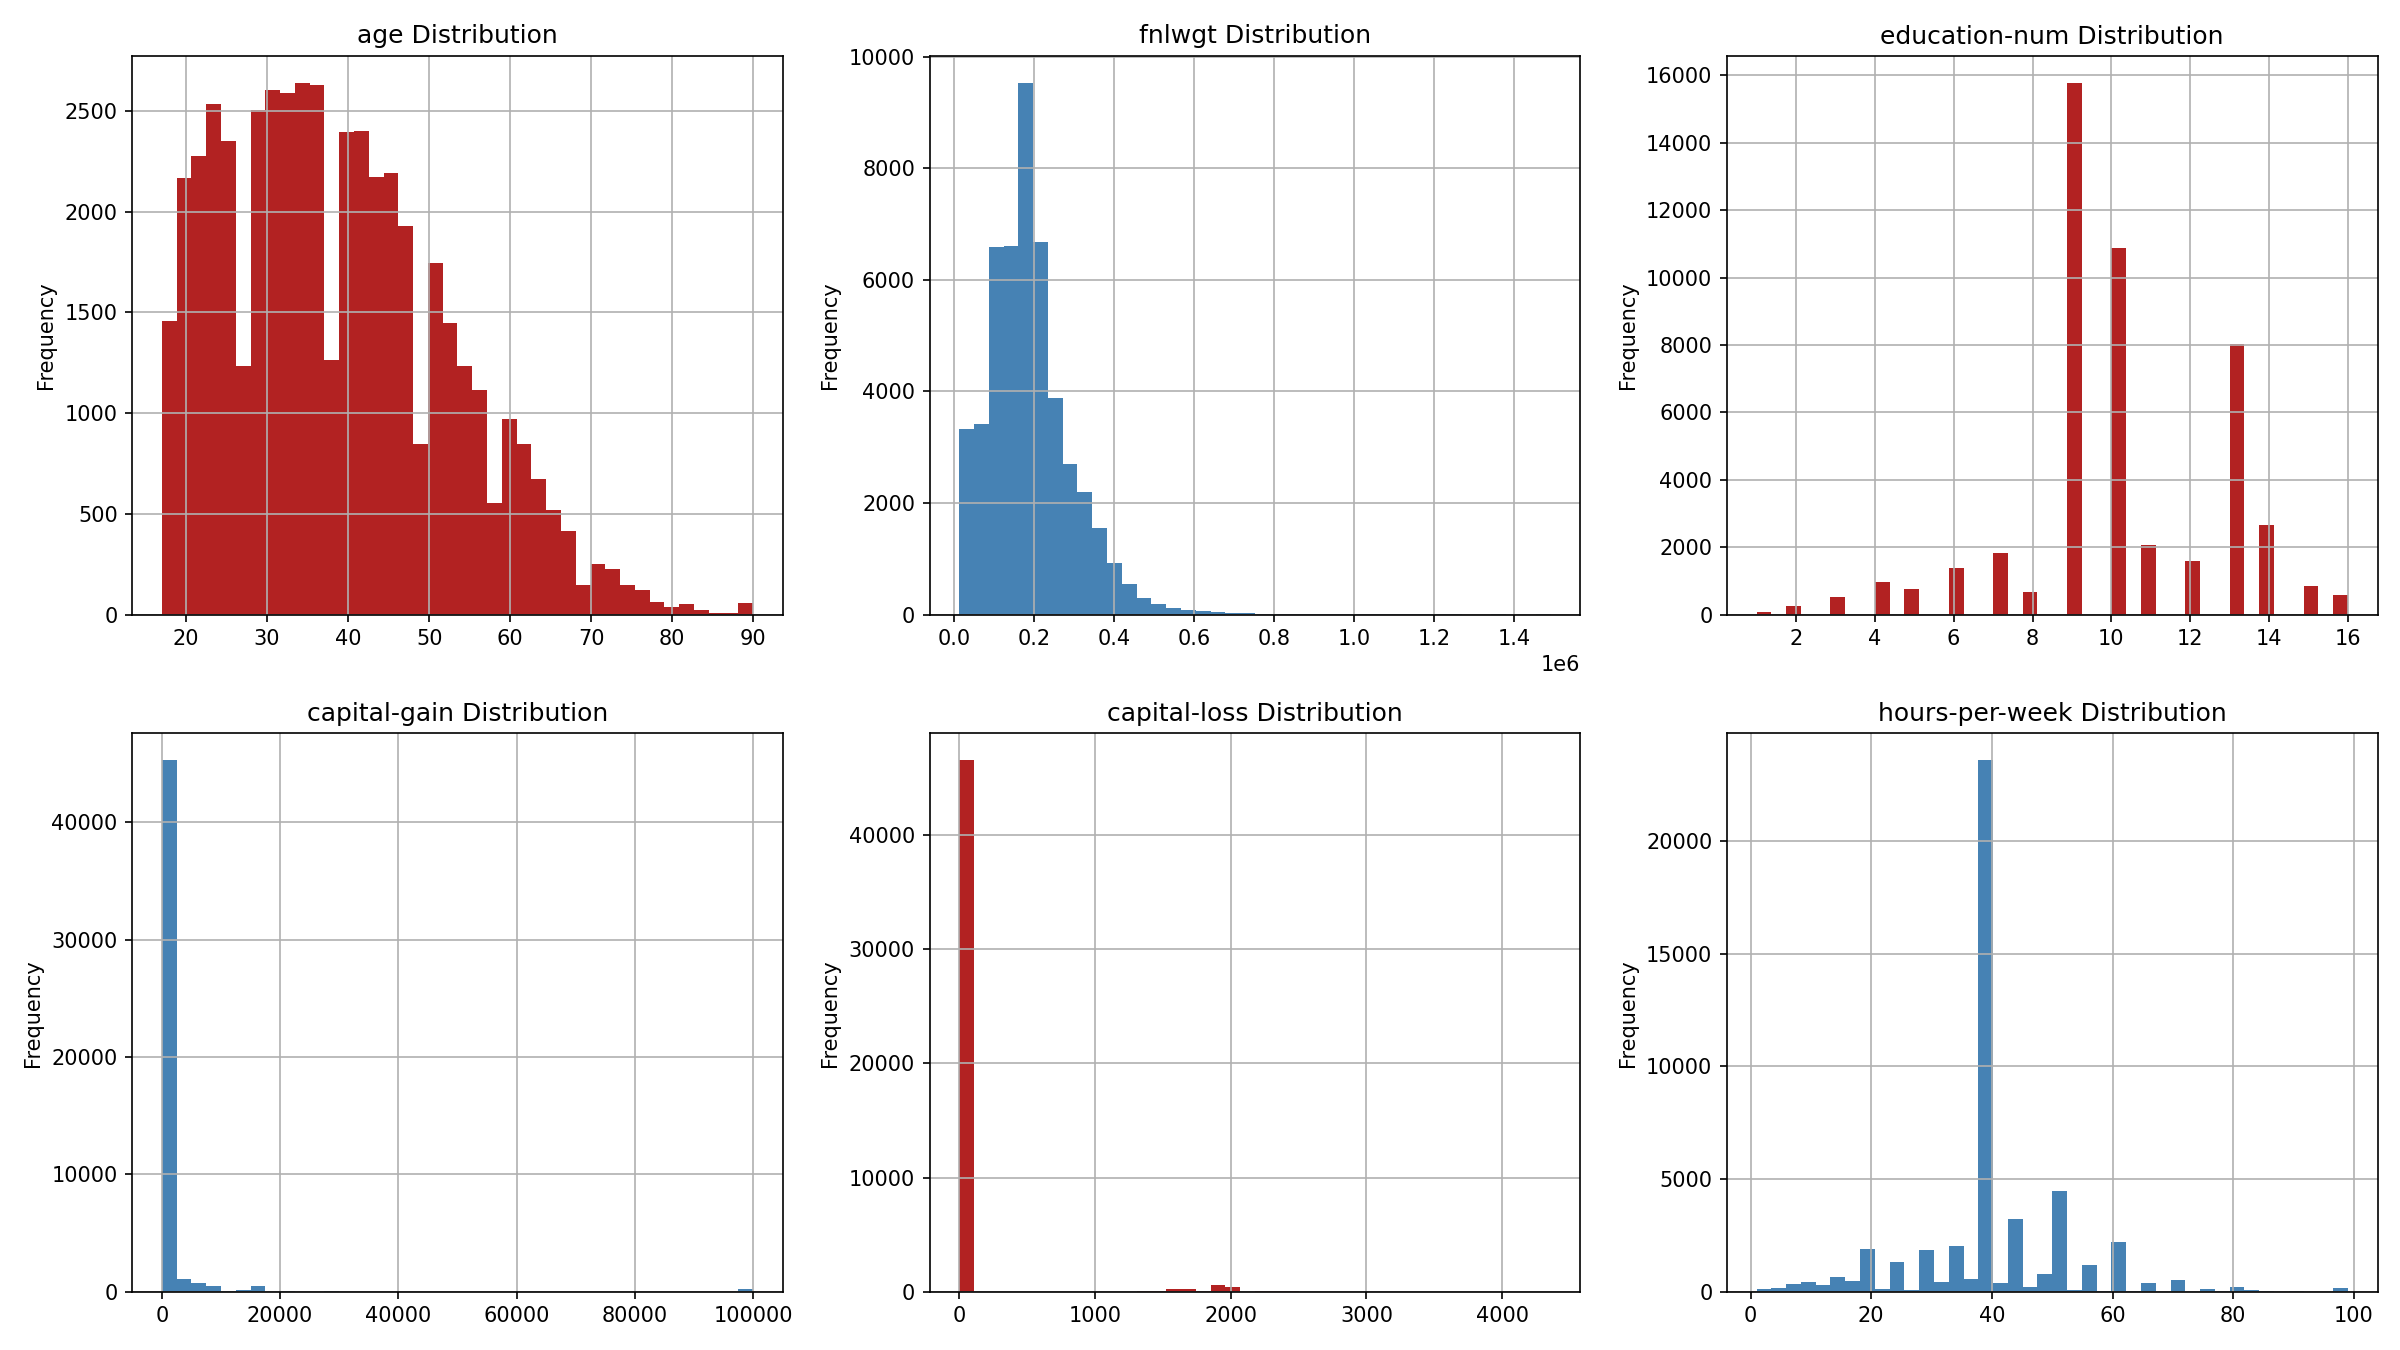


Categorical Variables vs Target Income


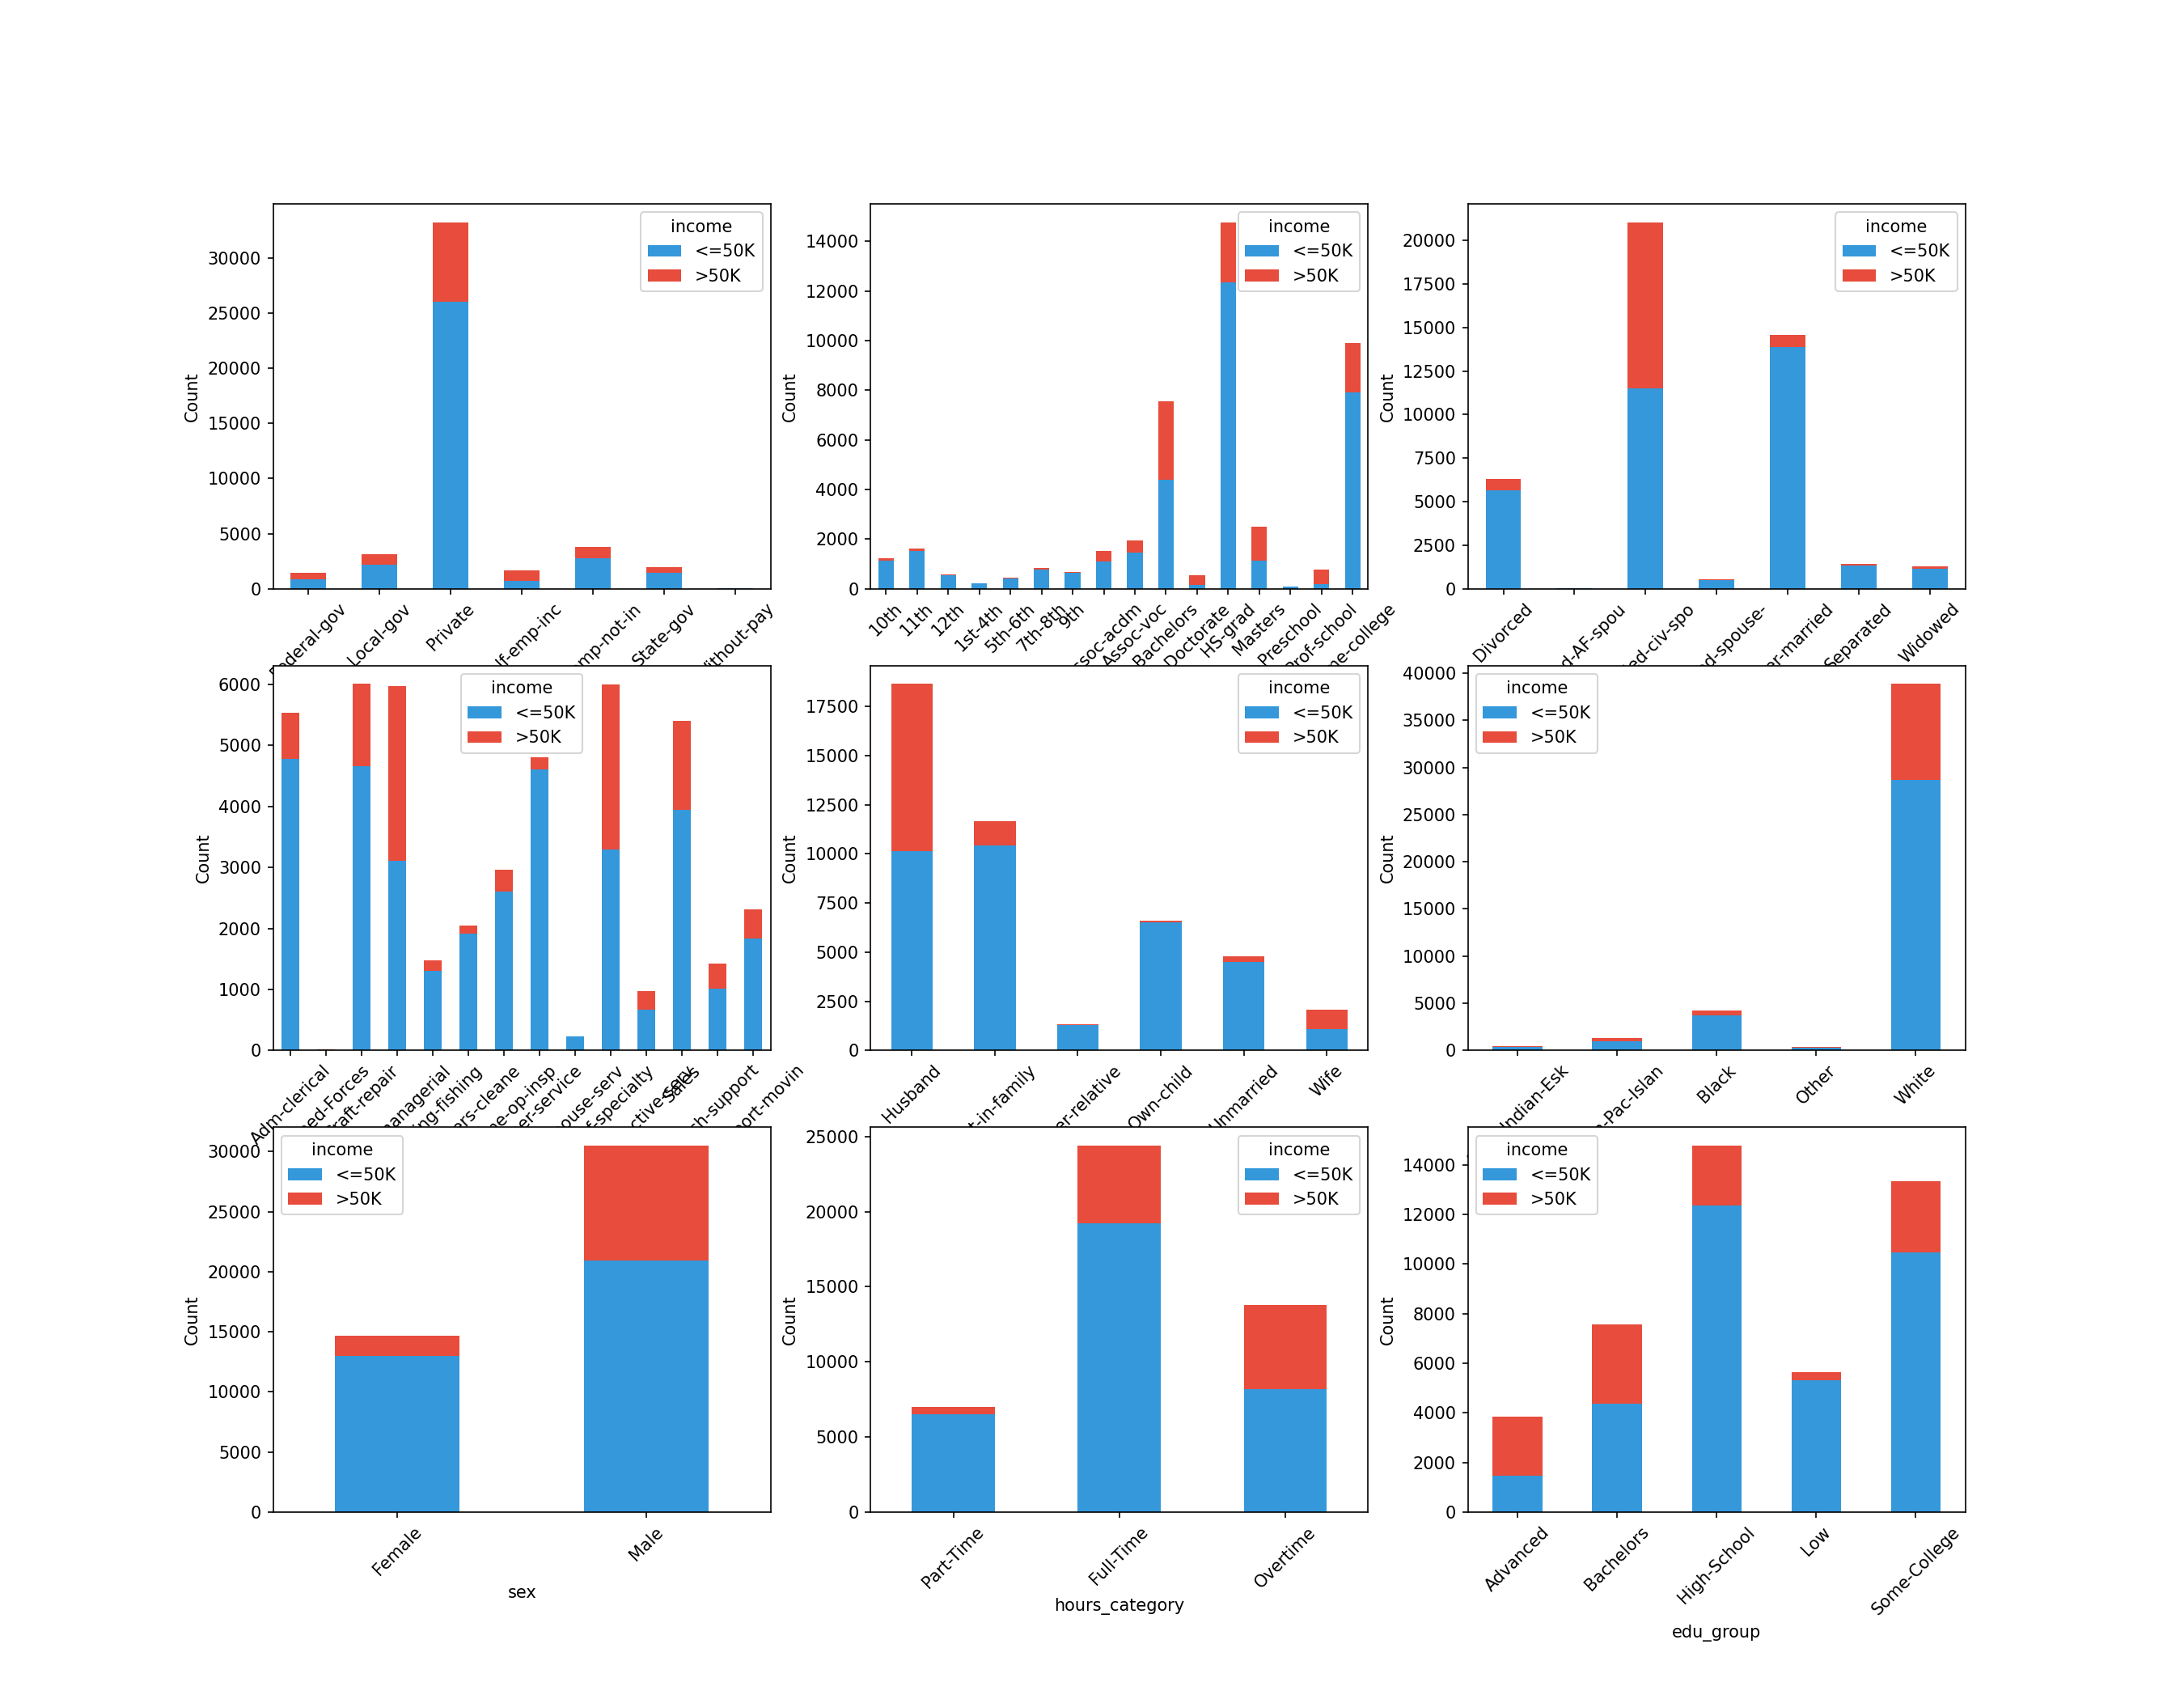

In [8]:
# EDA plots
df_raw = container.data_loader().load_raw_data()
plots_usecase = container.generate_eda_plots_usecase()
output_dir = os.path.join(os.getcwd(), "outputs/task2")
plots_usecase.execute(df_raw, df_processed, output_dir)

print("\nNumerical Features Distributions")
display(Image(os.path.join(output_dir, "numerical_distributions.png")))
print("\nCategorical Variables vs Target Income")
display(Image(os.path.join(output_dir, "categorical_vs_income.png")))
